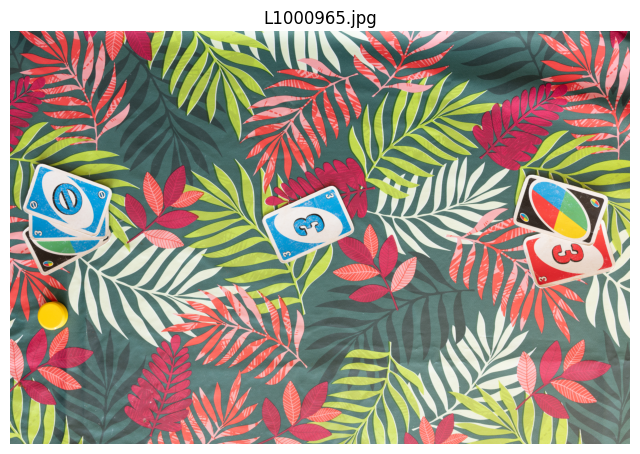

In [139]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

BASE_DIR = Path.cwd()
TRAIN_DIR = BASE_DIR / "iapr-26-uno-vision-challenge" / "train_images"

image_path = TRAIN_DIR / "L1000965.jpg" #L1000838 or L1000983
#image_path = BASE_DIR / "iapr-26-uno-vision-challenge" / "reference_images" / "L1000765.jpg"
img_color = Image.open(image_path).convert("RGB")

plt.figure(figsize=(8, 6))
plt.imshow(img_color)
plt.title(image_path.name)
plt.axis("off")
plt.show()


In [140]:
import numpy as np
import cv2

def extract_hsl_channels(img):
    """
    Extract HSL channels from the input image.

    Args
    ----
    img: np.ndarray (M, N, C)
        Input image of shape MxN and C channels.
    
    Return
    ------
    data_h: np.ndarray (M, N)
        Hue channel of input image
    data_s: np.ndarray (M, N)
        Saturation channel of input image
    data_l: np.ndarray (M, N)
        Lightness channel of input image
    """

    M, N, C = np.shape(img)
    data_h = np.zeros((M, N))
    data_s = np.zeros((M, N))
    data_l = np.zeros((M, N))

    hlsimg = cv2.cvtColor(img, cv2.COLOR_RGB2HLS)

    data_h = hlsimg[:, :, 0].astype(np.float32) * 2
    data_l = hlsimg[:, :, 1].astype(np.float32) / 255 * 100
    data_s = hlsimg[:, :, 2].astype(np.float32) / 255 * 100

    return data_h, data_s, data_l

def plot_colors_histo(img, func, labels):
    channels = func(img=img)
    C2 = len(channels)
    M, N, C1 = img.shape
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, C2)

    mask = np.random.RandomState(seed=0).rand(M, N) < 0.1

    ax = fig.add_subplot(gs[:2, :])
    ax.imshow(img)
    ax.axis('off')

    ax1 = fig.add_subplot(gs[2, 0])
    ax2 = fig.add_subplot(gs[2, 1])
    ax3 = fig.add_subplot(gs[2, 2])

    ax1.scatter(channels[0][mask].flatten(), channels[1][mask].flatten(), c=img[mask] / 255, s=1, alpha=0.1)
    ax1.set_xlabel(labels[0])
    ax1.set_ylabel(labels[1])
    ax1.set_title(f"{labels[0]} vs {labels[1]}")

    ax2.scatter(channels[0][mask].flatten(), channels[2][mask].flatten(), c=img[mask] / 255, s=1, alpha=0.1)
    ax2.set_xlabel(labels[0])
    ax2.set_ylabel(labels[2])
    ax2.set_title(f"{labels[0]} vs {labels[2]}")

    ax3.scatter(channels[1][mask].flatten(), channels[2][mask].flatten(), c=img[mask] / 255, s=1, alpha=0.1)
    ax3.set_xlabel(labels[1])
    ax3.set_ylabel(labels[2])
    ax3.set_title(f"{labels[1]} vs {labels[2]}")

    plt.tight_layout()
    plt.show()


In [141]:
'''plot_colors_histo(
    img=np.array(img_color),
    func=extract_hsl_channels,
    labels=["Hue", "Saturation", "Lightness"],
)'''


'plot_colors_histo(\n    img=np.array(img_color),\n    func=extract_hsl_channels,\n    labels=["Hue", "Saturation", "Lightness"],\n)'

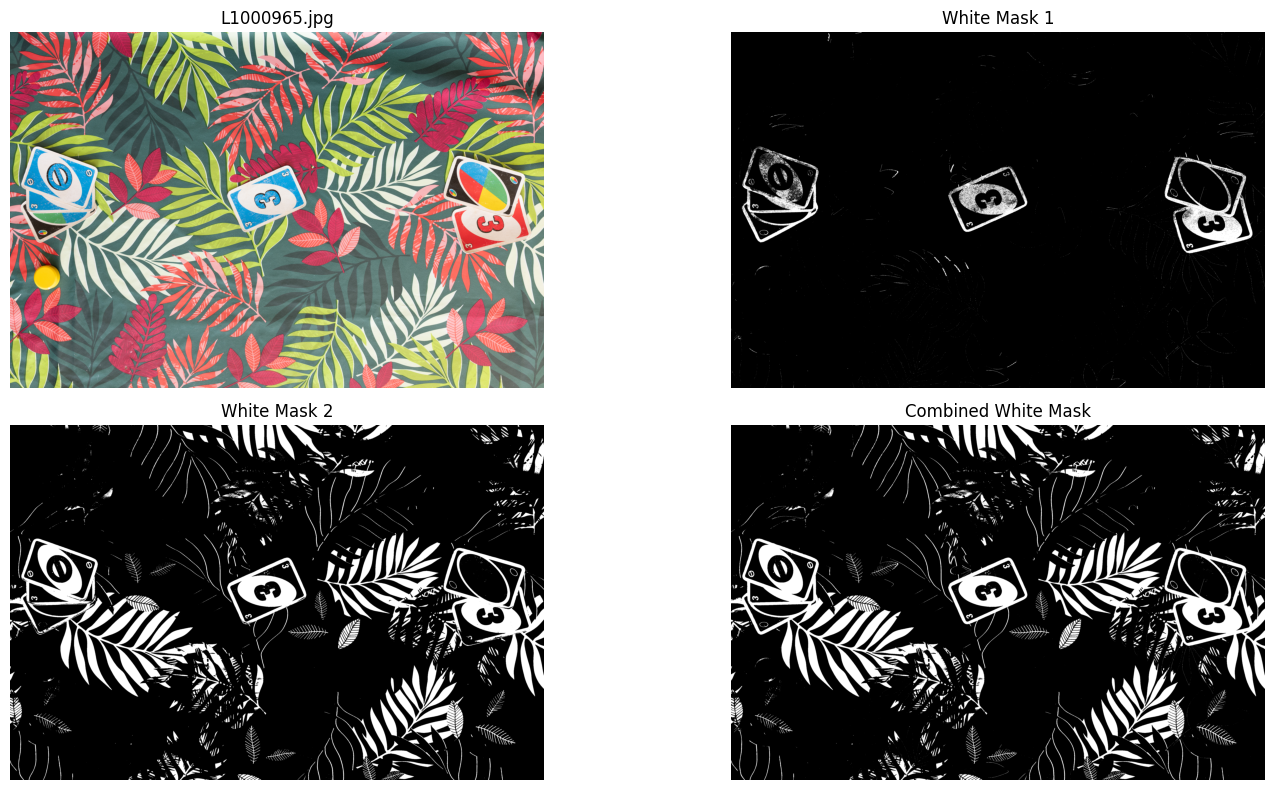

In [142]:
# Set two HSL threshold ranges and combine them into one mask
lower_white_1 = np.array([20.0, 0.0, 40.0])
upper_white_1 = np.array([40.0, 100.0, 100.0])

lower_white_2 = np.array([0.0, 0.0, 80.0])
upper_white_2 = np.array([360.0, 100.0, 100.0])

img_hls = cv2.cvtColor(np.array(img_color), cv2.COLOR_RGB2HLS)
img_hsl_regular = np.dstack((
    img_hls[:, :, 0].astype(np.float32) * 2,
    img_hls[:, :, 2].astype(np.float32) / 255 * 100,
    img_hls[:, :, 1].astype(np.float32) / 255 * 100,
))
white_mask_1 = np.all((img_hsl_regular >= lower_white_1) & (img_hsl_regular <= upper_white_1), axis=2)
white_mask_2 = np.all((img_hsl_regular >= lower_white_2) & (img_hsl_regular <= upper_white_2), axis=2)
white_mask = white_mask_1 | white_mask_2

plt.figure(figsize=(16, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_color)
plt.title(image_path.name)
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(white_mask_1, cmap="gray")
plt.title("White Mask 1")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(white_mask_2, cmap="gray")
plt.title("White Mask 2")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(white_mask, cmap="gray")
plt.title("Combined White Mask")
plt.axis("off")

plt.tight_layout()
plt.show()


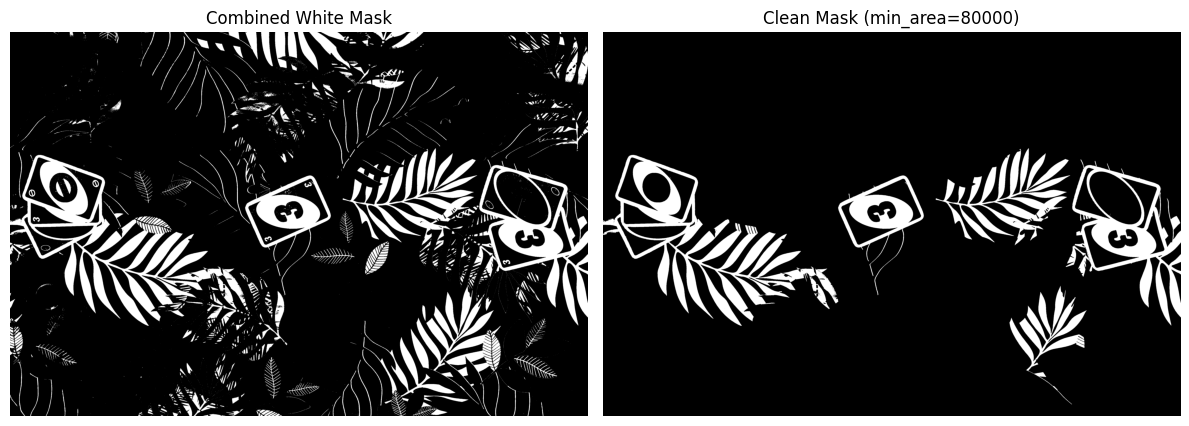

In [143]:
# Remove small connected areas from the combined white mask
min_area = 80000

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(white_mask.astype(np.uint8), connectivity=8)

clean_mask = np.zeros_like(white_mask, dtype=np.uint8)

for label in range(1, num_labels):
    area = stats[label, cv2.CC_STAT_AREA]
    if area >= min_area:
        clean_mask[labels == label] = 1

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(white_mask, cmap="gray")
plt.title("Combined White Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(clean_mask, cmap="gray")
plt.title(f"Clean Mask (min_area={min_area})")
plt.axis("off")

plt.tight_layout()
plt.show()


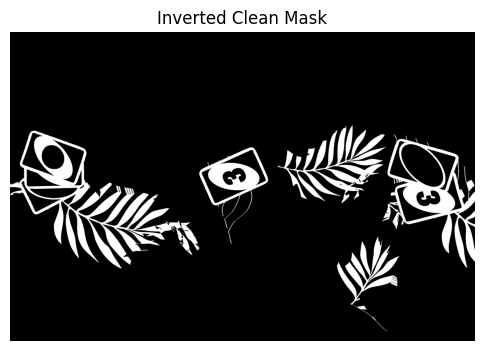

In [144]:
WHITE = None
if clean_mask.mean() >= 0.5:
    WHITE = True
    clean_mask = (1-clean_mask).astype(np.uint8)
else :
    WHITE = False
    clean_mask = (clean_mask).astype(np.uint8)
plt.figure(figsize=(6, 6))
plt.imshow(clean_mask, cmap="gray")
plt.title("Inverted Clean Mask")
plt.axis("off")
plt.show()

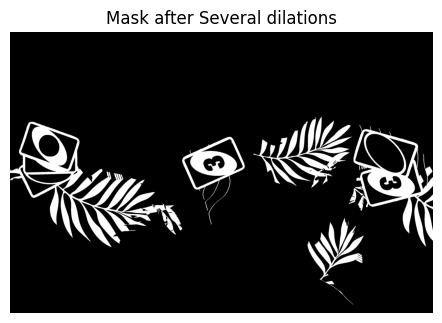

In [145]:
import cv2

morph_mask = clean_mask.copy()
if WHITE:
    kernel = np.ones((5, 5), np.uint8)
    morph_mask = cv2.morphologyEx(morph_mask, cv2.MORPH_ERODE, kernel,iterations=5)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(morph_mask, cmap="gray")
plt.title("Mask after Several dilations")
plt.axis("off")
plt.show()


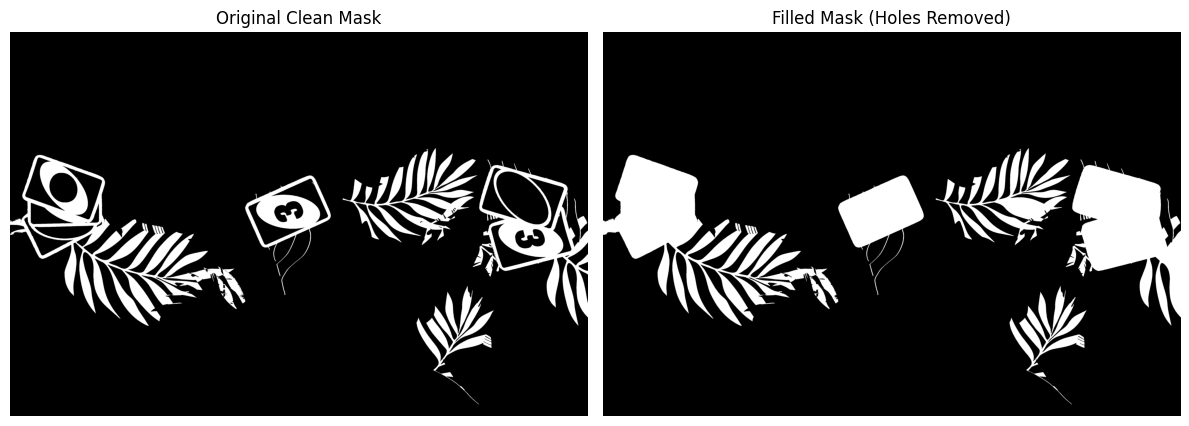

In [146]:
mask = (morph_mask > 0).astype(np.uint8) * 255
h, w = mask.shape
if not WHITE:
    floodfill_mask = np.zeros((h + 2, w + 2), dtype=np.uint8)

    mask_floodfill = mask.copy()
    cv2.floodFill(mask_floodfill, floodfill_mask, (0, 0), 255)

    holes = cv2.bitwise_not(mask_floodfill)
    filled_mask = ((mask | holes) // 255).astype(np.uint8)

    morph_mask = filled_mask
    edges = cv2.Canny(morph_mask * 255, 0, 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(mask, cmap="gray")
plt.title("Original Clean Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(morph_mask, cmap="gray")
plt.title("Filled Mask (Holes Removed)")
plt.axis("off")

plt.tight_layout()
plt.show()


##### dont fill holes that touch the border of the image
##### dont fill holes that touch the border of the image
##### dont fill holes that touch the border of the image
##### dont fill holes that touch the border of the image

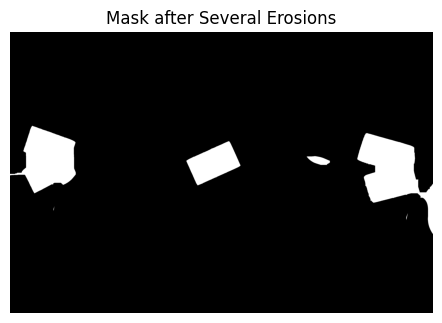

In [153]:
import cv2

eroded_mask_filled = morph_mask.copy()
if not WHITE:
    kernel = np.ones((5, 5), np.uint8)
    eroded_mask_filled = cv2.morphologyEx(eroded_mask_filled, cv2.MORPH_ERODE, kernel,iterations=15)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(eroded_mask_filled, cmap="gray")
plt.title("Mask after Several Erosions")
plt.axis("off")
plt.show()


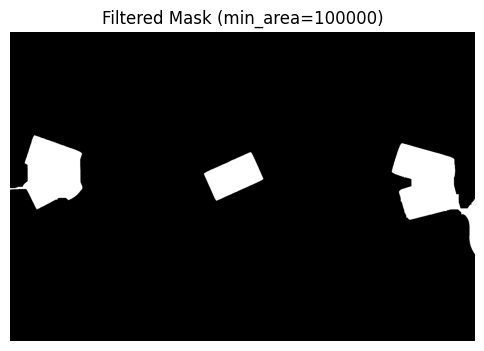

In [154]:
# Perform area filtering on the filled mask to remove small connected components
filtered_mask = eroded_mask_filled.copy()

num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(eroded_mask_filled.astype(np.uint8), connectivity=8)
if not WHITE:
    min_area_filed = 100000
    filtered_mask = np.zeros_like(eroded_mask_filled, dtype=np.uint8)

    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area >= min_area_filed:
            filtered_mask[labels == label] = 1
        
# Plot the filtered mask
plt.figure(figsize=(6, 6))
plt.imshow(filtered_mask, cmap="gray")
plt.title("Filtered Mask (min_area={})".format(min_area_filed))
plt.axis("off")
plt.show()

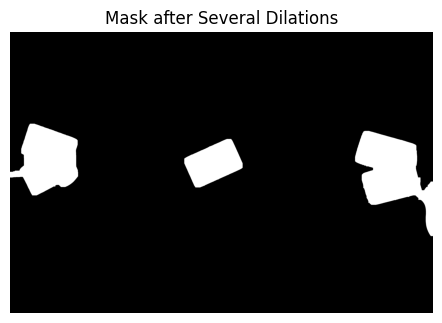

In [156]:
dilated_mask_filled = filtered_mask.copy()
if not WHITE:
    kernel = np.ones((5, 5), np.uint8)
    dilated_mask_filled = cv2.morphologyEx(dilated_mask_filled, cv2.MORPH_DILATE, kernel,iterations=10)
else:
    kernel = np.ones((5, 5), np.uint8)
    dilated_mask_filled = cv2.morphologyEx(dilated_mask_filled, cv2.MORPH_DILATE, kernel,iterations=3)


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(dilated_mask_filled, cmap="gray")
plt.title("Mask after Several Dilations")
plt.axis("off")
plt.show()

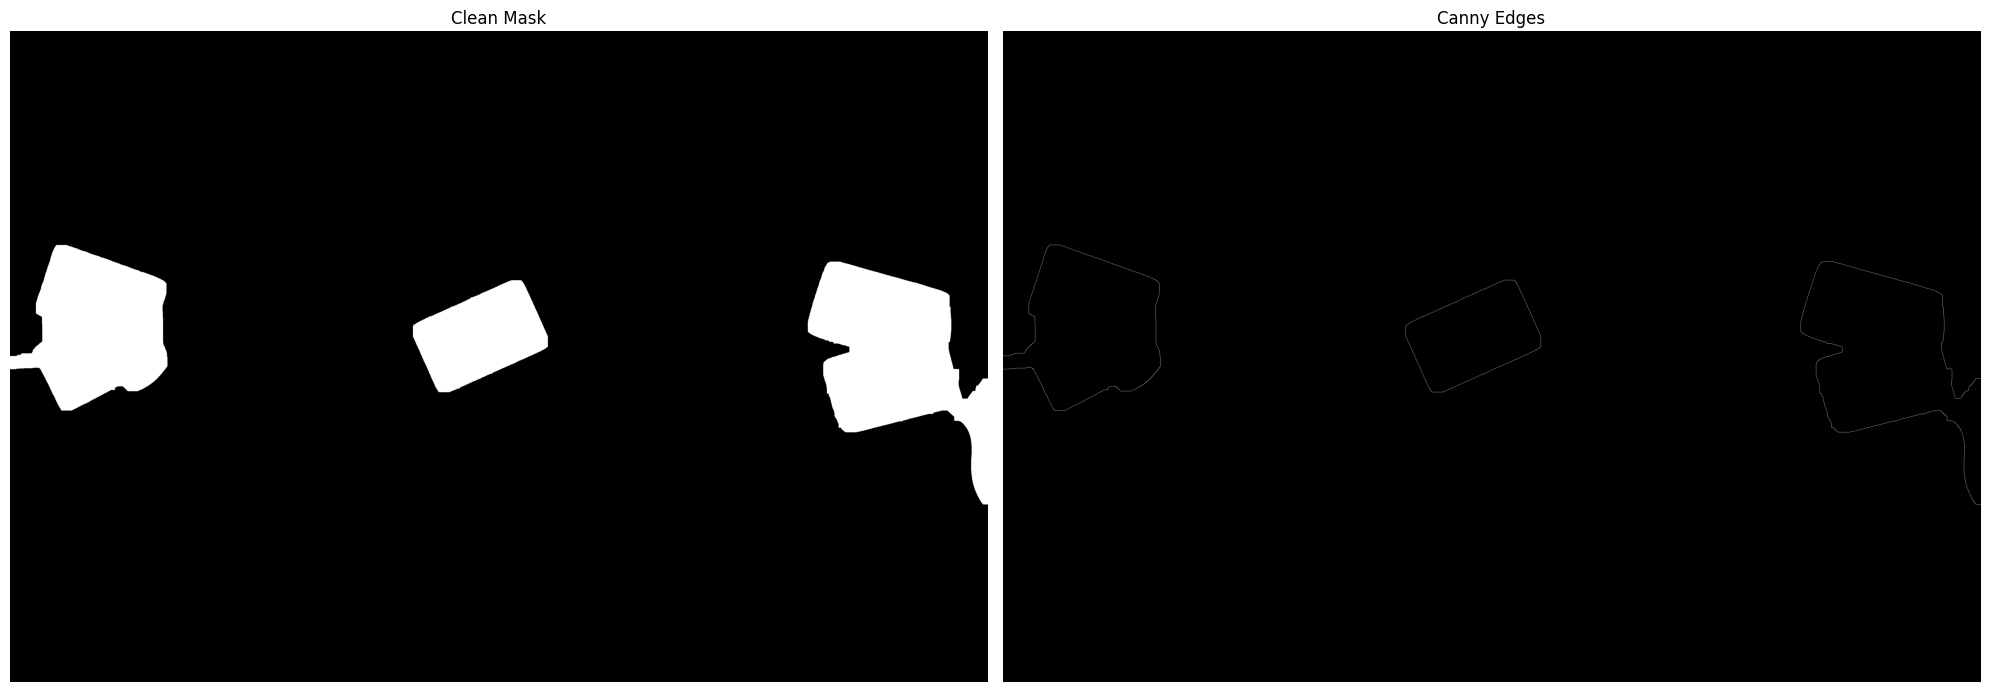

In [157]:
# Apply Canny edge detection on the cleaned white mask
edges = cv2.Canny((dilated_mask_filled.astype(np.uint8) * 255), 0, 0)

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.imshow(dilated_mask_filled, cmap="gray")
plt.title("Clean Mask")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()


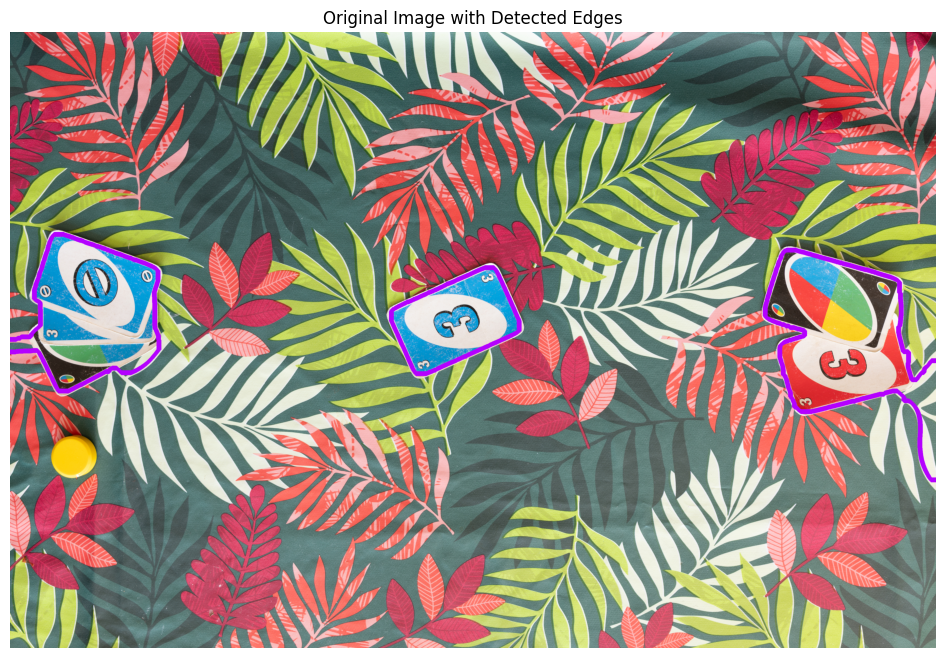

In [158]:
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
thick_edges = cv2.dilate(edges, kernel, iterations=10)

img_with_edges = np.array(img_color).copy()
img_with_edges[thick_edges > 0] = [180, 0, 255]  # Overlay edges in red

plt.figure(figsize=(12, 8))
plt.imshow(img_with_edges)
plt.title("Original Image with Detected Edges")
plt.axis("off")
plt.show()

In [159]:

'''
# Apply Hough Line Transform to detect lines in the edges
lines = cv2.HoughLinesP(edges, 5, np.pi / 180, threshold=10, minLineLength=200, maxLineGap=100)

# Draw the detected lines on a copy of the original image
img_with_lines = np.array(img_color).copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_with_lines, (x1, y1), (x2, y2), (180, 0, 255), 10)

plt.figure(figsize=(12, 8))
plt.imshow(img_with_lines)
plt.title("Detected Lines with Hough Transform")
plt.axis("off")
plt.show()'''

'\n# Apply Hough Line Transform to detect lines in the edges\nlines = cv2.HoughLinesP(edges, 5, np.pi / 180, threshold=10, minLineLength=200, maxLineGap=100)\n\n# Draw the detected lines on a copy of the original image\nimg_with_lines = np.array(img_color).copy()\nif lines is not None:\n    for line in lines:\n        x1, y1, x2, y2 = line[0]\n        cv2.line(img_with_lines, (x1, y1), (x2, y2), (180, 0, 255), 10)\n\nplt.figure(figsize=(12, 8))\nplt.imshow(img_with_lines)\nplt.title("Detected Lines with Hough Transform")\nplt.axis("off")\nplt.show()'